# Churn Prediction Model Training

**Goal:** Train an XGBoost model to predict `internet_churn` (0 or 1) using service + customer demographic features.

**Datasets:**
- `internet_data.csv` — service records (plan, usage, complaints, churn label)
- `trilink_customers_data.csv` — customer demographics (age, income, home ownership)

**Steps:**
1. Load & explore data
2. Join tables on customer_id
3. Feature engineering & preprocessing
4. Train/test split
5. Train XGBoost model
6. Evaluate performance

In [ ]:
# Install dependencies if needed
# !pip install pandas scikit-learn xgboost matplotlib seaborn

: 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

## 1. Load & Explore Data

In [2]:
# Load both datasets
internet_df = pd.read_csv('data/internet_data.csv')
customers_df = pd.read_csv('data/trilink_customers_data.csv')

print(f'Internet data: {internet_df.shape[0]} rows, {internet_df.shape[1]} columns')
print(f'Customer data: {customers_df.shape[0]} rows, {customers_df.shape[1]} columns')

Internet data: 72756 rows, 17 columns
Customer data: 100000 rows, 18 columns


In [3]:
# Explore internet/service data
print('--- Internet Data ---')
print(internet_df.dtypes)
print()
internet_df.head()

--- Internet Data ---
service_id                     object
customer_id                    object
plan_tier                      object
speed_mbps                      int64
monthly_cost                    int64
data_usage_gb                   int64
connected_devices               int64
start_date                     object
end_date                       object
contract_type                  object
contract_end_date              object
speed_complaints                int64
outage_count                    int64
internet_churn                  int64
early_termination               int64
internet_tenure_days          float64
contract_completed_percent    float64
dtype: object



,service_id,customer_id,plan_tier,speed_mbps,monthly_cost,data_usage_gb,connected_devices,start_date,end_date,contract_type,contract_end_date,speed_complaints,outage_count,internet_churn,early_termination,internet_tenure_days,contract_completed_percent
0,INT_00000001,C00000001,Premium_Gig,1000,100,595,12,2023-03-31,NaN,Month_to_Month,NaN,0,0,0,0,890.0,NaN
1,INT_00000002,C00000002,Premium_Gig,1000,95,469,21,2023-06-30,NaN,12_Month,2026-06-30,0,1,0,0,799.0,72.901460
2,INT_00000003,C00000003,Basic_25,25,47,50,8,2022-12-06,2024-07-24,Month_to_Month,NaN,3,3,1,0,596.0,NaN
3,INT_00000004,C00000004,Basic_25,25,46,50,5,2025-05-08,NaN,12_Month,2026-05-08,0,2,0,0,121.0,33.150685
4,INT_00000005,C00000005,Basic_25,25,43,50,13,2023-09-05,NaN,Month_to_Month,NaN,2,0,0,0,732.0,NaN


In [4]:
# Explore customer demographic data
print('--- Customer Data ---')
print(customers_df.dtypes)
print()
customers_df.head()

--- Customer Data ---
customer_id                    object
city                           object
postal_code                    object
age                             int64
household_income                int64
income_bracket                 object
family_size                     int64
home_ownership                 object
work_from_home_flag              bool
education_level                object
life_stage                     object
home_type                      object
home_square_footage             int64
property_value                  int64
neighborhood_crime_rate       float64
neighborhood_income_median      int64
fiber_availability               bool
created_timestamp              object
dtype: object



,customer_id,city,postal_code,age,household_income,income_bracket,family_size,home_ownership,work_from_home_flag,education_level,life_stage,home_type,home_square_footage,property_value,neighborhood_crime_rate,neighborhood_income_median,fiber_availability,created_timestamp
0,C00000001,Toronto,M1A 4H3,46,251996,High,3,Own,True,Professional,Established_Family,Single_Family,5000,2000000,5.0,81574,True,2025-09-06 12:52:18.374917
1,C00000002,Toronto,M2Z 1X8,38,267027,High,4,Own,True,Professional,Established_Family,Townhouse,5000,2000000,3.9,95130,False,2025-09-06 12:52:18.374917
2,C00000003,Mississauga,L1U 6B0,32,77650,Middle,1,Own,False,HS,Single,Townhouse,693,311014,4.7,68326,True,2025-09-06 12:52:18.376926
3,C00000004,Toronto,M1G 3S9,26,50000,Low,2,Own,True,College,Single,Condo,659,144168,4.5,94296,False,2025-09-06 12:52:18.376926
4,C00000005,London,N0T 3Y8,49,111316,Upper_Middle,4,Own,False,Professional,Established_Family,Single_Family,3544,663169,6.6,30000,False,2025-09-06 12:52:18.376926


Churn distribution:
internet_churn
0    59009
1    13747
Name: count, dtype: int64

Churn rate: 18.89%


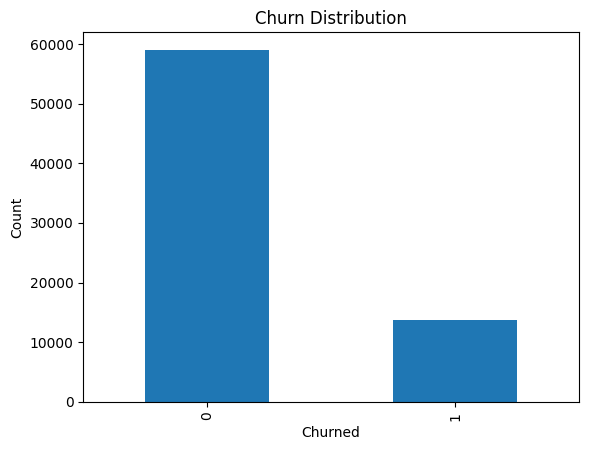

In [5]:
# Check churn class balance — important for model training
print('Churn distribution:')
print(internet_df['internet_churn'].value_counts())
print()
print(f'Churn rate: {internet_df["internet_churn"].mean():.2%}')

internet_df['internet_churn'].value_counts().plot(kind='bar', title='Churn Distribution')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

In [6]:
# Check for nulls in both datasets
print('--- Internet Data Nulls ---')
print(internet_df.isnull().sum())
print()
print('--- Customer Data Nulls ---')
print(customers_df.isnull().sum())

--- Internet Data Nulls ---
service_id                        0
customer_id                       0
plan_tier                         0
speed_mbps                        0
monthly_cost                      0
data_usage_gb                     0
connected_devices                 0
start_date                        0
end_date                      59009
contract_type                     0
contract_end_date             31940
speed_complaints                  0
outage_count                      0
internet_churn                    0
early_termination                 0
internet_tenure_days              0
contract_completed_percent    31940
dtype: int64

--- Customer Data Nulls ---
customer_id                   0
city                          0
postal_code                   0
age                           0
household_income              0
income_bracket                0
family_size                   0
home_ownership                0
work_from_home_flag           0
education_level               

## 2. Join Tables on customer_id

In [7]:
# Merge on customer_id — inner join so we only keep customers with internet service
df = internet_df.merge(customers_df, on='customer_id', how='inner')
print(f'Merged dataset: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Merged dataset: 72756 rows, 34 columns


,service_id,customer_id,plan_tier,speed_mbps,monthly_cost,data_usage_gb,connected_devices,start_date,end_date,contract_type,...,work_from_home_flag,education_level,life_stage,home_type,home_square_footage,property_value,neighborhood_crime_rate,neighborhood_income_median,fiber_availability,created_timestamp
0,INT_00000001,C00000001,Premium_Gig,1000,100,595,12,2023-03-31,NaN,Month_to_Month,...,True,Professional,Established_Family,Single_Family,5000,2000000,5.0,81574,True,2025-09-06 12:52:18.374917
1,INT_00000002,C00000002,Premium_Gig,1000,95,469,21,2023-06-30,NaN,12_Month,...,True,Professional,Established_Family,Townhouse,5000,2000000,3.9,95130,False,2025-09-06 12:52:18.374917
2,INT_00000003,C00000003,Basic_25,25,47,50,8,2022-12-06,2024-07-24,Month_to_Month,...,False,HS,Single,Townhouse,693,311014,4.7,68326,True,2025-09-06 12:52:18.376926
3,INT_00000004,C00000004,Basic_25,25,46,50,5,2025-05-08,NaN,12_Month,...,True,College,Single,Condo,659,144168,4.5,94296,False,2025-09-06 12:52:18.376926
4,INT_00000005,C00000005,Basic_25,25,43,50,13,2023-09-05,NaN,Month_to_Month,...,False,Professional,Established_Family,Single_Family,3544,663169,6.6,30000,False,2025-09-06 12:52:18.376926


## 3. Feature Engineering & Preprocessing

In [8]:
# Drop columns that would leak info or aren't useful for prediction
drop_cols = [
    'service_id',         # just an ID
    'customer_id',        # just an ID
    'start_date',         # captured by internet_tenure_days
    'end_date',           # leaky — only filled for churned customers
    'contract_end_date',  # leaky — related to churn timing
    'early_termination',  # leaky — directly related to churn
    'city',               # too many unique values (high cardinality)
    'postal_code',        # too many unique values
    'created_timestamp',  # account creation timestamp, not predictive
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print(f'After dropping: {df.shape[1]} columns remaining')
print(df.columns.tolist())

After dropping: 25 columns remaining
['plan_tier', 'speed_mbps', 'monthly_cost', 'data_usage_gb', 'connected_devices', 'contract_type', 'speed_complaints', 'outage_count', 'internet_churn', 'internet_tenure_days', 'contract_completed_percent', 'age', 'household_income', 'income_bracket', 'family_size', 'home_ownership', 'work_from_home_flag', 'education_level', 'life_stage', 'home_type', 'home_square_footage', 'property_value', 'neighborhood_crime_rate', 'neighborhood_income_median', 'fiber_availability']


In [9]:
# Identify categorical vs numeric columns
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('internet_churn')  # don't include the target

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numeric columns ({len(num_cols)}): {num_cols}')

Categorical columns (9): ['plan_tier', 'contract_type', 'income_bracket', 'home_ownership', 'work_from_home_flag', 'education_level', 'life_stage', 'home_type', 'fiber_availability']
Numeric columns (15): ['speed_mbps', 'monthly_cost', 'data_usage_gb', 'connected_devices', 'speed_complaints', 'outage_count', 'internet_tenure_days', 'contract_completed_percent', 'age', 'household_income', 'family_size', 'home_square_footage', 'property_value', 'neighborhood_crime_rate', 'neighborhood_income_median']


In [10]:
# Check unique values for each categorical column
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique — {df[col].unique()[:10]}')

plan_tier: 3 unique — ['Premium_Gig' 'Basic_25' 'Standard_100']
contract_type: 3 unique — ['Month_to_Month' '12_Month' '24_Month']
income_bracket: 4 unique — ['High' 'Middle' 'Low' 'Upper_Middle']
home_ownership: 3 unique — ['Own' 'Rent' 'Other']
work_from_home_flag: 2 unique — [ True False]
education_level: 4 unique — ['Professional' 'HS' 'College' 'Graduate']
life_stage: 5 unique — ['Established_Family' 'Single' 'Senior' 'Empty_Nest' 'Young_Family']
home_type: 4 unique — ['Single_Family' 'Townhouse' 'Condo' 'Apartment']
fiber_availability: 2 unique — [ True False]


In [11]:
# Label encode categorical columns
# XGBoost can handle encoded categoricals well
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Encoded plan_tier: {'Basic_25': 0, 'Premium_Gig': 1, 'Standard_100': 2}
Encoded contract_type: {'12_Month': 0, '24_Month': 1, 'Month_to_Month': 2}
Encoded income_bracket: {'High': 0, 'Low': 1, 'Middle': 2, 'Upper_Middle': 3}
Encoded home_ownership: {'Other': 0, 'Own': 1, 'Rent': 2}
Encoded work_from_home_flag: {'False': 0, 'True': 1}
Encoded education_level: {'College': 0, 'Graduate': 1, 'HS': 2, 'Professional': 3}
Encoded life_stage: {'Empty_Nest': 0, 'Established_Family': 1, 'Senior': 2, 'Single': 3, 'Young_Family': 4}
Encoded home_type: {'Apartment': 0, 'Condo': 1, 'Single_Family': 2, 'Townhouse': 3}
Encoded fiber_availability: {'False': 0, 'True': 1}


In [12]:
# Handle any remaining nulls
print(f'Nulls remaining: {df.isnull().sum().sum()}')
df = df.fillna(0)  # fill remaining nulls with 0
print(f'Final shape: {df.shape}')
df.head()

Nulls remaining: 31940
Final shape: (72756, 25)


,plan_tier,speed_mbps,monthly_cost,data_usage_gb,connected_devices,contract_type,speed_complaints,outage_count,internet_churn,internet_tenure_days,...,home_ownership,work_from_home_flag,education_level,life_stage,home_type,home_square_footage,property_value,neighborhood_crime_rate,neighborhood_income_median,fiber_availability
0,1,1000,100,595,12,2,0,0,0,890.0,...,1,1,3,1,2,5000,2000000,5.0,81574,1
1,1,1000,95,469,21,0,0,1,0,799.0,...,1,1,3,1,3,5000,2000000,3.9,95130,0
2,0,25,47,50,8,2,3,3,1,596.0,...,1,0,2,3,3,693,311014,4.7,68326,1
3,0,25,46,50,5,0,0,2,0,121.0,...,1,1,0,3,1,659,144168,4.5,94296,0
4,0,25,43,50,13,2,2,0,0,732.0,...,1,0,3,1,2,3544,663169,6.6,30000,0


## 4. Train/Test Split

In [13]:
# Separate features and target
X = df.drop(columns=['internet_churn'])
y = df['internet_churn']

# 80/20 split, stratified to maintain churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')
print(f'Train churn rate: {y_train.mean():.2%}')
print(f'Test churn rate:  {y_test.mean():.2%}')

Training set: 58204 rows
Test set:     14552 rows
Train churn rate: 18.89%
Test churn rate:  18.90%


## 5. Train XGBoost Model

In [14]:
# Calculate scale_pos_weight to handle class imbalance
# This tells XGBoost to pay more attention to the minority class (churn=1)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# Train XGBoost classifier
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=20  # print every 20 rounds
)

print('Training complete!')

scale_pos_weight: 4.29
[0]	validation_0-logloss:0.62786
[20]	validation_0-logloss:0.26398
[40]	validation_0-logloss:0.22463
[60]	validation_0-logloss:0.21247
[80]	validation_0-logloss:0.20708
[100]	validation_0-logloss:0.20303
[120]	validation_0-logloss:0.20004
[140]	validation_0-logloss:0.19803
[160]	validation_0-logloss:0.19664
[180]	validation_0-logloss:0.19462
[199]	validation_0-logloss:0.19328
Training complete!


## 6. Evaluate Performance

In [15]:
# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Classification report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# AUC score
auc = roc_auc_score(y_test, y_pred_proba)
print(f'AUC-ROC Score: {auc:.4f}')

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.97      0.93      0.95     11802
       Churn       0.74      0.89      0.81      2750

    accuracy                           0.92     14552
   macro avg       0.86      0.91      0.88     14552
weighted avg       0.93      0.92      0.92     14552

AUC-ROC Score: 0.9724


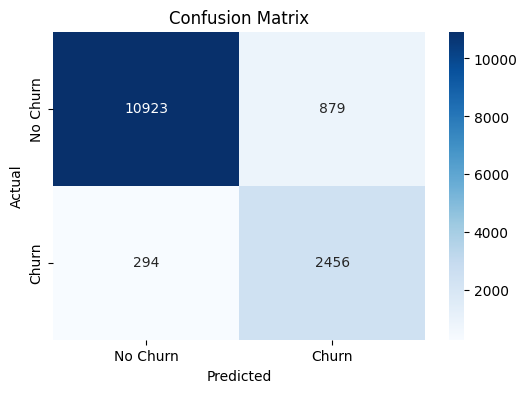

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

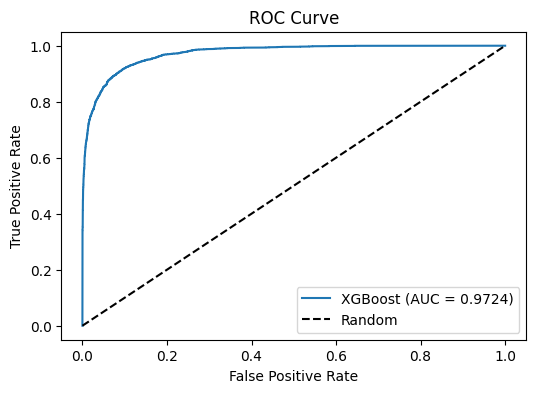

In [17]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

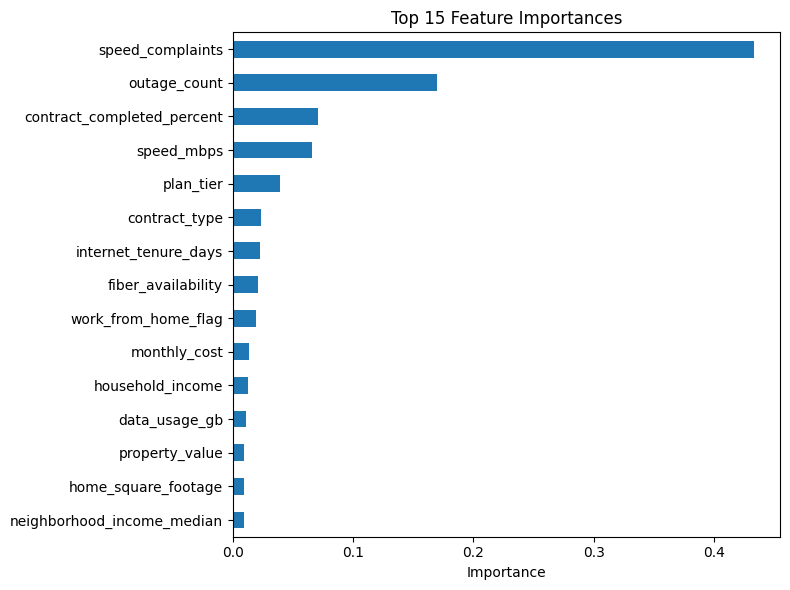

In [18]:
# Feature importance — top 15
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True).tail(15)

plt.figure(figsize=(8, 6))
importance.plot(kind='barh')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Save Model

Save the trained model locally. Later we'll upload to S3 and deploy as a SageMaker endpoint.

In [19]:
import joblib
import json

# Save the model
joblib.dump(model, 'churn_model.joblib')
print('Model saved to churn_model.joblib')

# Save the label encoders so the FastAPI wrapper can decode inputs
encoder_mapping = {}
for col, le in label_encoders.items():
    encoder_mapping[col] = dict(zip(le.classes_.tolist(), le.transform(le.classes_).tolist()))

with open('label_encoders.json', 'w') as f:
    json.dump(encoder_mapping, f, indent=2)
print('Label encoders saved to label_encoders.json')

# Save the feature order for the FastAPI wrapper
with open('feature_columns.json', 'w') as f:
    json.dump(X.columns.tolist(), f)
print('Feature columns saved to feature_columns.json')

Model saved to churn_model.joblib
Label encoders saved to label_encoders.json
Feature columns saved to feature_columns.json
